In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Yoga Pose Classifier — Built From Scratch
### Custom CNN + MediaPipe Keypoints Fusion | 8 Classes | GPU-Ready

**Architecture overview:**
- Branch 1: Custom CNN (no pretrained weights) — learns visual features
- Branch 2: MediaPipe skeleton (33 landmarks) — encodes body geometry
- Fusion head: combines both branches → 8-class output

Run cells top to bottom. Edit only **Cell 3** to set your data path.

## Cell 1 — Install dependencies (run once)

In [3]:
!pip install mediapipe==0.10.13 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
# Uncomment and run once, then restart the kernel
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install mediapipe opencv-python albumentations scikit-learn matplotlib seaborn tqdm grad-cam

## Cell 2 — Imports & GPU check

In [4]:
import os, random, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2
import mediapipe as mp
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU found — training will be slow. Consider Google Colab for GPU.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Cell 3 — Configuration  ← EDIT YOUR PATHS HERE

In [6]:
# ── EDIT THESE ────────────────────────────────────────────────────────────
DATA_DIR  = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/')   # root folder of your dataset
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
CKPT_PATH = Path('checkpoints/best_scratch_model.pth')
CKPT_PATH.parent.mkdir(exist_ok=True)

# ── PICK YOUR 8 CLASSES ───────────────────────────────────────────────────
SELECTED_CLASSES = None  # auto-detect from folder names

# ── HYPERPARAMETERS ───────────────────────────────────────────────────────
IMG_SIZE     = 128
BATCH_SIZE   = 32
NUM_CLASSES  = 8
EPOCHS       = 60
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── AUTO TRAIN/VAL SPLIT if val folder is missing ─────────────────────────
import shutil, random as _random
_random.seed(42)

if not VAL_DIR.exists() or not any(VAL_DIR.iterdir()):
    print('Val folder missing — creating 80/20 split from train...')
    VAL_DIR.mkdir(parents=True, exist_ok=True)
    src_classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    for cls in src_classes:
        cls_src = TRAIN_DIR / cls
        cls_val = VAL_DIR / cls
        cls_val.mkdir(parents=True, exist_ok=True)
        imgs = list(cls_src.glob('*.jpg')) + list(cls_src.glob('*.jpeg')) + list(cls_src.glob('*.png'))
        _random.shuffle(imgs)
        cut = int(len(imgs) * 0.8)
        val_imgs = imgs[cut:]
        # move 20% to val (non-destructive copy then remove from train)
        for p in val_imgs:
            shutil.move(str(p), str(cls_val / p.name))
        remaining = len(imgs) - len(val_imgs)
        print(f'  {cls:<30} train: {remaining}  val: {len(val_imgs)}')
    print('Split complete!')
else:
    print('Val folder already exists — skipping split.')

# Auto-detect class names
if SELECTED_CLASSES:
    CLASS_NAMES = SELECTED_CLASSES
else:
    CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])[:NUM_CLASSES]

print(f'\nClasses ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'Train dir : {TRAIN_DIR}')
print(f'Val dir   : {VAL_DIR}')
# verify counts
for cls in CLASS_NAMES:
    tr = len(list((TRAIN_DIR / cls).glob('*.*')))
    vl = len(list((VAL_DIR   / cls).glob('*.*')))
    print(f'  {cls:<30} train: {tr:>4}  val: {vl:>4}')


Val folder already exists — skipping split.

Classes (8): ['adho mukha svanasana', 'balasana', 'bhujangasana', 'chaturanga dandasana', 'dandasana', 'virabhadrasana i', 'virabhadrasana ii', 'vriksasana']
Train dir : /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train
Val dir   : /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/val
  adho mukha svanasana           train:  500  val:    0
  balasana                       train:  500  val:    0
  bhujangasana                   train:  500  val:    0
  chaturanga dandasana           train:  500  val:    0
  dandasana                      train:  500  val:    0
  virabhadrasana i               train:  500  val:    0
  virabhadrasana ii              train:  500  val:    0
  vriksasana                     train:  500  val:    0


## Cell 4 — MediaPipe keypoint extractor

In [7]:
import mediapipe as mp
import numpy as np
import cv2
import urllib.request
import os

print(f"MediaPipe version: {mp.__version__}")

KP_DIM     = 99
MODEL_PATH = '/content/pose_landmarker.task'

# Download pose model once
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model (~5MB)...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',
        MODEL_PATH
    )
    print("Done!")

BaseOptions           = mp.tasks.BaseOptions
PoseLandmarker        = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode     = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE
)

def extract_keypoints(image_path):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return np.zeros(KP_DIM, dtype=np.float32)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    with PoseLandmarker.create_from_options(options) as detector:
        result = detector.detect(mp_image)
    if result.pose_landmarks and len(result.pose_landmarks) > 0:
        lm = result.pose_landmarks[0]
        kp = np.array([[l.x, l.y, l.visibility] for l in lm], dtype=np.float32)
        hip_mid      = (kp[23, :2] + kp[24, :2]) / 2
        shoulder_mid = (kp[11, :2] + kp[12, :2]) / 2
        torso        = np.linalg.norm(shoulder_mid - hip_mid) + 1e-6
        kp[:, :2]    = (kp[:, :2] - hip_mid) / torso
        return kp.flatten()
    return np.zeros(KP_DIM, dtype=np.float32)

def count_valid_keypoints(cache):
    if len(cache) == 0:
        print("  No images found — check folder path!")
        return
    valid = sum(1 for v in cache.values() if np.any(v != 0))
    total = len(cache)
    print(f"  Pose detected: {valid}/{total} ({100*valid/total:.1f}%)")

print(f"Keypoint extractor ready — output dim: {KP_DIM}")

MediaPipe version: 0.10.13
Done!
Keypoint extractor ready — output dim: 99


In [15]:
import shutil, random
from pathlib import Path

random.seed(42)

# ── Step 1: Find where the class folders actually are ─────────────────────
DATA_ROOT = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data')
CLASS_NAMES = [
    'adho mukha svanasana', 'virabhadrasana i', 'virabhadrasana ii',
    'vriksasana', 'bhujangasana', 'balasana', 'dandasana', 'chaturanga dandasana'
]

SOURCE_DIR = None
for folder in sorted(DATA_ROOT.rglob('*/')):
    subdirs = [d for d in folder.iterdir() if d.is_dir()]
    names   = [d.name for d in subdirs]
    # check if any of our class names exist here
    matches = [n for n in names if n in CLASS_NAMES]
    if len(matches) >= 4:
        SOURCE_DIR = folder
        print(f"Found class folders at: {SOURCE_DIR}")
        print(f"Matched classes: {matches}")
        break

if SOURCE_DIR is None:
    print("ERROR: Could not find class folders!")
    print("Listing everything under /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/dataa:")
    for f in sorted(DATA_ROOT.rglob('*/'))[:30]:
        print(f"  {f}")

Found class folders at: /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train
Matched classes: ['adho mukha svanasana', 'virabhadrasana i', 'virabhadrasana ii', 'vriksasana', 'bhujangasana', 'balasana', 'dandasana', 'chaturanga dandasana']


In [12]:
# ── Step 2: Create clean train/val split ─────────────────────────────────
TRAIN_DIR = Path('/content/data/yoga_split/train')
VAL_DIR   = Path('/content/data/yoga_split/val')

print(f'\n{"Class":<30} {"Train":>8} {"Val":>6}')
print('-' * 48)

for cls in CLASS_NAMES:
    cls_src = SOURCE_DIR / cls
    if not cls_src.exists():
        print(f'  NOT FOUND: {cls}')
        continue

    imgs = (list(cls_src.glob('*.jpg')) +
            list(cls_src.glob('*.jpeg')) +
            list(cls_src.glob('*.png')))
    random.shuffle(imgs)
    cut = int(len(imgs) * 0.8)

    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (VAL_DIR   / cls).mkdir(parents=True, exist_ok=True)

    for img in imgs[:cut]:
        shutil.copy(img, TRAIN_DIR / cls / img.name)
    for img in imgs[cut:]:
        shutil.copy(img, VAL_DIR / cls / img.name)

    print(f'{cls:<30} {cut:>8} {len(imgs)-cut:>6}')

print('\nDone! Now update Cell 3:')
print('  TRAIN_DIR = Path("/content/data/yoga_split/train")')
print('  VAL_DIR   = Path("/content/data/yoga_split/val")')


Class                             Train    Val
------------------------------------------------
adho mukha svanasana                400    100
virabhadrasana i                    400    100
virabhadrasana ii                   400    100
vriksasana                          400    100
bhujangasana                        400    100
balasana                            400    100
dandasana                           400    100
chaturanga dandasana                400    100

Done! Now update Cell 3:
  TRAIN_DIR = Path("/content/data/yoga_split/train")
  VAL_DIR   = Path("/content/data/yoga_split/val")


In [13]:
# ── Step 3: Update paths and re-run cache build ───────────────────────────
TRAIN_DIR = Path('/content/data/yoga_split/train')
VAL_DIR   = Path('/content/data/yoga_split/val')

# verify
print("Verification:")
for cls in CLASS_NAMES:
    tr = len(list((TRAIN_DIR / cls).glob('*.*')))
    vl = len(list((VAL_DIR   / cls).glob('*.*')))
    print(f'  {cls:<30} train: {tr:>4}  val: {vl:>4}')

Verification:
  adho mukha svanasana           train:  400  val:  100
  virabhadrasana i               train:  400  val:  100
  virabhadrasana ii              train:  400  val:  100
  vriksasana                     train:  400  val:  100
  bhujangasana                   train:  400  val:  100
  balasana                       train:  400  val:  100
  dandasana                      train:  400  val:  100
  chaturanga dandasana           train:  400  val:  100


## Cell 5 — Build keypoint cache (run once ~3–5 min)

In [14]:
from tqdm.notebook import tqdm

def build_cache(root_dir):
    cache = {}
    paths = []
    for cls in CLASS_NAMES:
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            paths.extend((root_dir / cls).glob(ext))

    with PoseLandmarker.create_from_options(options) as detector:
        for p in tqdm(paths, desc=f'Extracting from {root_dir.name}'):
            img_bgr = cv2.imread(str(p))
            if img_bgr is None:
                cache[str(p)] = np.zeros(KP_DIM, dtype=np.float32)
                continue
            img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result   = detector.detect(mp_image)
            if result.pose_landmarks and len(result.pose_landmarks) > 0:
                lm = result.pose_landmarks[0]
                kp = np.array([[l.x, l.y, l.visibility] for l in lm], dtype=np.float32)
                hip_mid      = (kp[23, :2] + kp[24, :2]) / 2
                shoulder_mid = (kp[11, :2] + kp[12, :2]) / 2
                torso        = np.linalg.norm(shoulder_mid - hip_mid) + 1e-6
                kp[:, :2]    = (kp[:, :2] - hip_mid) / torso
                cache[str(p)] = kp.flatten()
            else:
                cache[str(p)] = np.zeros(KP_DIM, dtype=np.float32)
    return cache

print("Building keypoint caches...")
train_kp_cache = build_cache(TRAIN_DIR)
val_kp_cache   = build_cache(VAL_DIR)
print("Train:", end=" "); count_valid_keypoints(train_kp_cache)
print("Val:  ", end=" "); count_valid_keypoints(val_kp_cache)

Building keypoint caches...


Extracting from train:   0%|          | 0/3200 [00:00<?, ?it/s]

Extracting from val:   0%|          | 0/800 [00:00<?, ?it/s]

Train:   Pose detected: 2026/3200 (63.3%)
Val:     Pose detected: 499/800 (62.4%)


## Cell 6 — Dataset & augmentation

In [16]:
class YogaDataset(Dataset):
    def __init__(self, root_dir, class_names, kp_cache, transform=None):
        self.samples    = []
        self.kp_cache   = kp_cache
        self.transform  = transform
        for label, cls in enumerate(class_names):
            for ext in ('*.jpg','*.jpeg','*.png'):
                for p in (Path(root_dir) / cls).glob(ext):
                    self.samples.append((str(p), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        kp = torch.tensor(self.kp_cache.get(path, np.zeros(KP_DIM)), dtype=torch.float32)
        return img, kp, label


# Heavy augmentation — critical when training from scratch with limited data
train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.3),                          # careful with asymmetric poses
    A.RandomBrightnessContrast(0.3, 0.3, p=0.5),
    A.HueSaturationValue(10, 20, 10, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=12, p=0.6),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.CoarseDropout(max_holes=6, max_height=16, max_width=16, p=0.4),  # occlusion
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

train_ds = YogaDataset(TRAIN_DIR, CLASS_NAMES, train_kp_cache, train_tf)
val_ds   = YogaDataset(VAL_DIR,   CLASS_NAMES, val_kp_cache,   val_tf)

# Weighted sampler to handle class imbalance
labels      = [s[1] for s in train_ds.samples]
class_count = np.bincount(labels)
weights     = 1.0 / class_count[labels]
sampler     = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,   num_workers=4, pin_memory=True)

print(f'Train : {len(train_ds)} images')
print(f'Val   : {len(val_ds)} images')
print(f'Per-class counts: {dict(zip(CLASS_NAMES, class_count))}')

Train : 3200 images
Val   : 800 images
Per-class counts: {'adho mukha svanasana': np.int64(400), 'virabhadrasana i': np.int64(400), 'virabhadrasana ii': np.int64(400), 'vriksasana': np.int64(400), 'bhujangasana': np.int64(400), 'balasana': np.int64(400), 'dandasana': np.int64(400), 'chaturanga dandasana': np.int64(400)}


## Cell 7 — Explore dataset (sample grid)

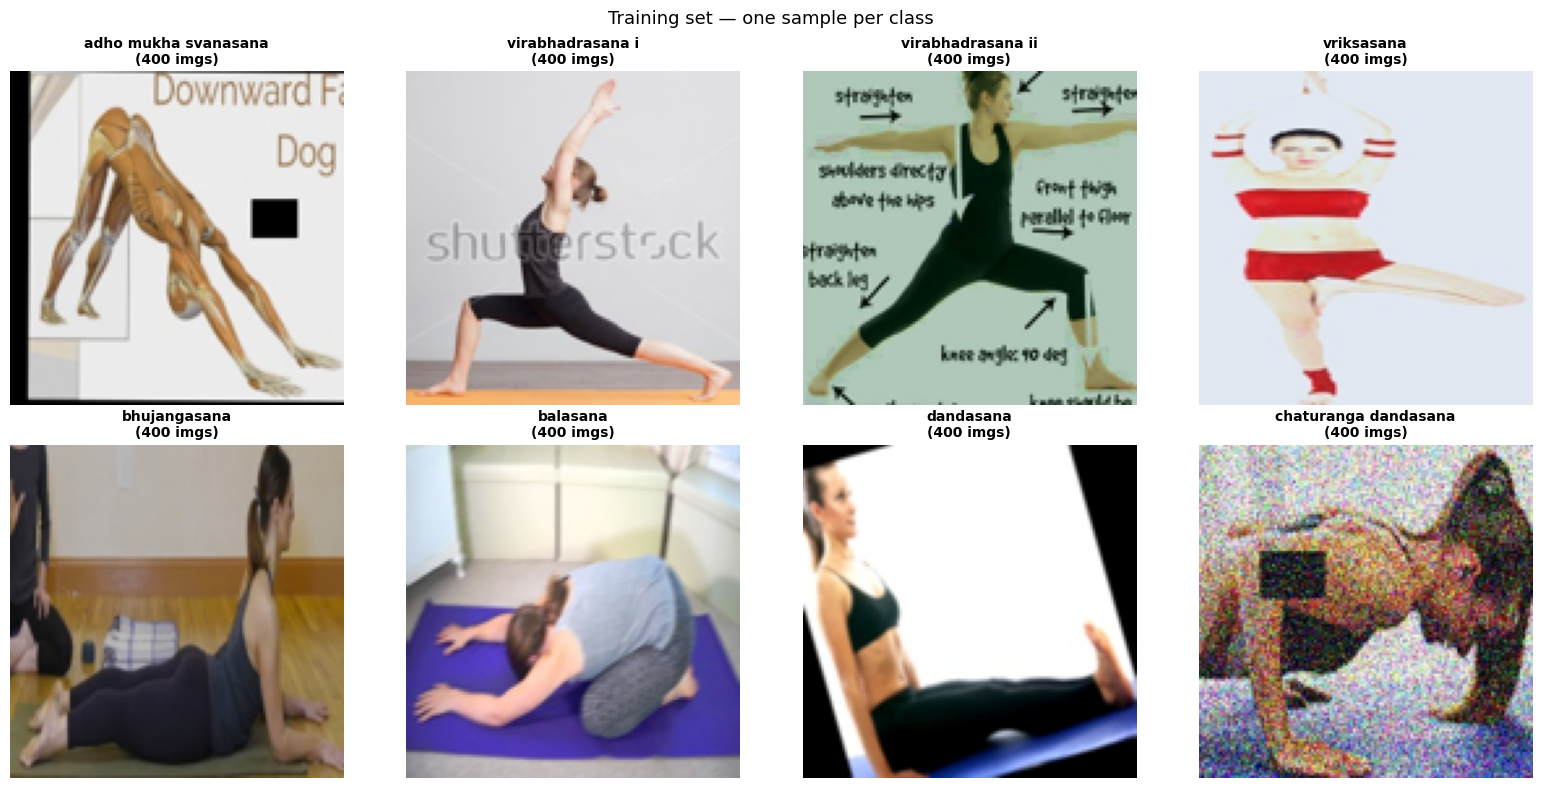

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg')) + list((TRAIN_DIR / cls).glob('*.png'))
    if imgs:
        img = np.array(Image.open(imgs[0]).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        ax.imshow(img)
        n = len(list((TRAIN_DIR / cls).glob('*.*')))
        ax.set_title(f'{cls}\n({n} imgs)', fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('Training set — one sample per class', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 8 — Custom CNN architecture (from scratch)

Design choices for limited data:
- 4 conv blocks with BatchNorm + GELU — more stable than ReLU from scratch
- Progressive channel widening: 32 → 64 → 128 → 256
- Spatial Attention module — focuses on body regions, ignores background
- Aggressive Dropout — prevents overfitting on small dataset
- Global Average Pooling — fewer parameters than Flatten + FC

In [18]:
class ConvBlock(nn.Module):
    """Conv → BN → GELU → Conv → BN → GELU → MaxPool with residual shortcut."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
        # 1x1 shortcut to match channels
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(self.block(x) + self.shortcut(x))


class SpatialAttention(nn.Module):
    """Highlights body regions, suppresses background clutter."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * att


class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation: re-weights feature channels."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w


class CustomCNN(nn.Module):
    """
    4-block CNN with residual shortcuts + CBAM-style attention.
    Input: (B, 3, 128, 128) → Output: feature vector (256-dim)
    """
    def __init__(self):
        super().__init__()
        # Stem: initial feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.GELU()
        )
        # 4 conv blocks: 128→64→32→16→8
        self.block1 = ConvBlock(32,  64)
        self.block2 = ConvBlock(64,  128)
        self.block3 = ConvBlock(128, 256)
        self.block4 = ConvBlock(256, 256)

        # Attention modules
        self.spatial_att = SpatialAttention()
        self.channel_att = ChannelAttention(256)

        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.out_dim = 256

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.spatial_att(x)   # attend to body regions
        x = self.block4(x)
        x = self.channel_att(x)   # weight informative channels
        x = self.gap(x).flatten(1)
        return self.dropout(x)


class KeypointEncoder(nn.Module):
    """MLP to encode 99-dim skeleton vector into 128-dim features."""
    def __init__(self, in_dim=99, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.GELU(),
        )
    def forward(self, x): return self.net(x)


class YogaModel(nn.Module):
    """
    Dual-branch fusion model:
      - Custom CNN for image features (256-dim)
      - Keypoint encoder for skeleton geometry (128-dim)
      - Concat → FC head → 8-class output
    """
    def __init__(self, num_classes=8):
        super().__init__()
        self.cnn = CustomCNN()
        self.kp  = KeypointEncoder()
        fused    = self.cnn.out_dim + 128  # 384
        self.head = nn.Sequential(
            nn.Linear(fused, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, kp):
        return self.head(torch.cat([self.cnn(img), self.kp(kp)], dim=1))


model = YogaModel(NUM_CLASSES).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
print(f'Model size      : ~{total*4/1e6:.1f} MB')

Total params    : 2,596,650
Trainable params: 2,596,650
Model size      : ~10.4 MB


## Cell 9 — Training setup

In [19]:
# Label smoothing reduces overconfidence — very helpful training from scratch
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

# AdamW with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warm-up for 5 epochs then cosine decay
def lr_lambda(epoch):
    warmup = 5
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (EPOCHS - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Mixup augmentation — blends two images to help generalization
def mixup_data(x, kp, y, alpha=0.4):
    if alpha <= 0: return x, kp, y, y, 1.0
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0)).to(x.device)
    return (lam*x + (1-lam)*x[idx],
            lam*kp + (1-lam)*kp[idx],
            y, y[idx], lam)

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

print('Optimizer, scheduler, and Mixup ready.')
print(f'Starting LR  : {LR}')
print(f'Training for : {EPOCHS} epochs')

Optimizer, scheduler, and Mixup ready.
Starting LR  : 0.001
Training for : 60 epochs


## Cell 10 — Full training loop

In [21]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, kps, labels in loader:
        imgs, kps, labels = imgs.to(DEVICE), kps.to(DEVICE), labels.to(DEVICE)

        # Apply Mixup
        imgs_m, kps_m, ya, yb, lam = mixup_data(imgs, kps, labels, alpha=0.4)

        optimizer.zero_grad()
        logits = model(imgs_m, kps_m)
        loss   = mixup_loss(criterion, logits, ya, yb, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, kps, labels in loader:
        imgs, kps, labels = imgs.to(DEVICE), kps.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs, kps)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ─── Main Training Loop ────────────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}
best_val_acc  = 0.0
patience      = 15
no_improve    = 0

print(f'Training from scratch for {EPOCHS} epochs on {DEVICE}\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['lr'].append(lr)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        no_improve = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_acc': best_val_acc, 'class_names': CLASS_NAMES,
                    'img_size': IMG_SIZE}, CKPT_PATH)
        flag = '  ✓ saved'
    else:
        no_improve += 1

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train {tr_acc:.3f} | val {vl_acc:.3f} | '
          f'loss {vl_loss:.4f} | lr {lr:.2e}{flag}')

    # Early stopping
    if no_improve >= patience:
        print(f'\nEarly stop at epoch {epoch} — no improvement for {patience} epochs.')
        break

print(f'\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')

Training from scratch for 60 epochs on cuda

Epoch   1/60 | train 0.539 | val 0.910 | loss 0.8301 | lr 8.15e-07  ✓ saved
Epoch   2/60 | train 0.541 | val 0.910 | loss 0.8325 | lr 3.26e-06
Epoch   3/60 | train 0.515 | val 0.906 | loss 0.8386 | lr 7.32e-06
Epoch   4/60 | train 0.490 | val 0.911 | loss 0.8298 | lr 1.30e-05  ✓ saved
Epoch   5/60 | train 0.518 | val 0.909 | loss 0.8324 | lr 2.03e-05
Epoch   6/60 | train 0.551 | val 0.906 | loss 0.8275 | lr 2.91e-05
Epoch   7/60 | train 0.542 | val 0.910 | loss 0.8306 | lr 3.94e-05
Epoch   8/60 | train 0.525 | val 0.914 | loss 0.8277 | lr 5.13e-05  ✓ saved
Epoch   9/60 | train 0.578 | val 0.907 | loss 0.8275 | lr 6.46e-05
Epoch  10/60 | train 0.452 | val 0.912 | loss 0.8291 | lr 7.94e-05
Epoch  11/60 | train 0.513 | val 0.911 | loss 0.8345 | lr 9.55e-05
Epoch  12/60 | train 0.562 | val 0.912 | loss 0.8298 | lr 1.13e-04
Epoch  13/60 | train 0.549 | val 0.910 | loss 0.8274 | lr 1.32e-04
Epoch  14/60 | train 0.473 | val 0.919 | loss 0.8251 | lr

## Cell 11 — Training curves

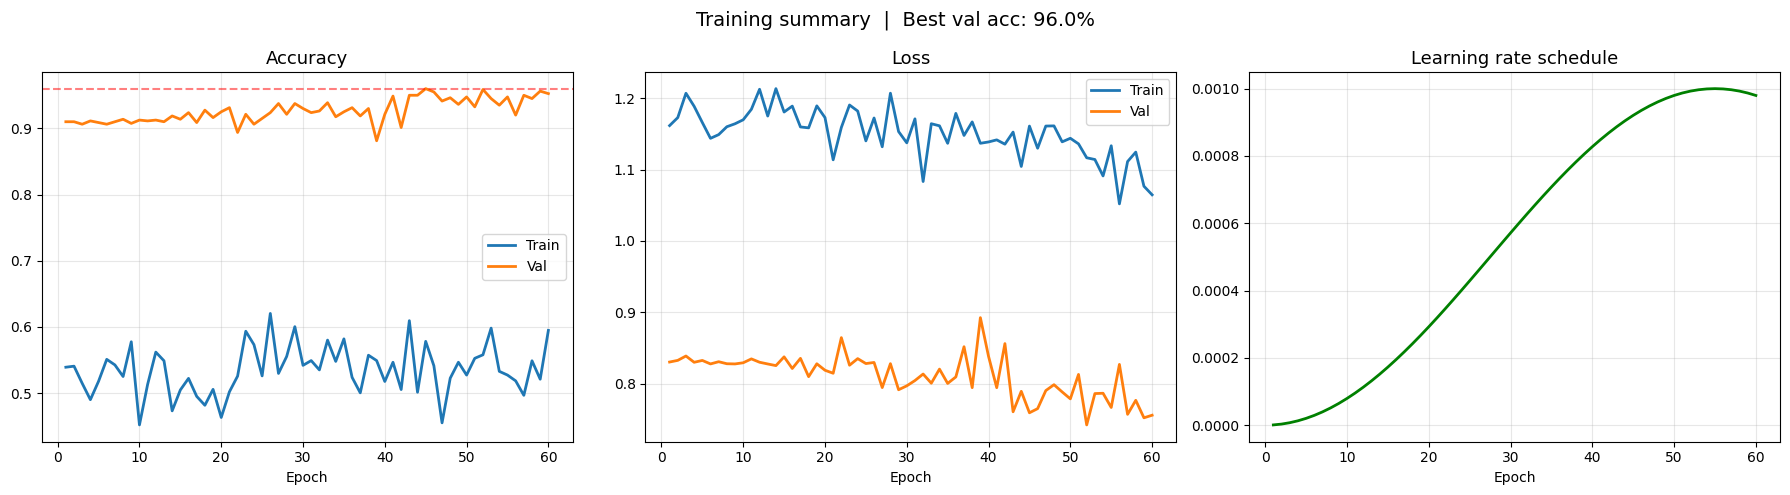

In [22]:
epochs_range = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_acc'], label='Train', lw=2)
axes[0].plot(epochs_range, history['val_acc'],   label='Val',   lw=2)
axes[0].set_title('Accuracy',  fontsize=13); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(best_val_acc, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.3f}')

axes[1].plot(epochs_range, history['train_loss'], label='Train', lw=2)
axes[1].plot(epochs_range, history['val_loss'],   label='Val',   lw=2)
axes[1].set_title('Loss', fontsize=13); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['lr'], color='green', lw=2)
axes[2].set_title('Learning rate schedule', fontsize=13); axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Training summary  |  Best val acc: {best_val_acc*100:.1f}%', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Load best model & evaluate

In [23]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best checkpoint — epoch {ckpt["epoch"]}, val acc {ckpt["val_acc"]:.4f}')

model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, kps, labels in val_loader:
        imgs, kps = imgs.to(DEVICE), kps.to(DEVICE)
        logits = model(imgs, kps)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

Loaded best checkpoint — epoch 45, val acc 0.9600

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

adho mukha svanasana     0.9789    0.9300    0.9538       100
    virabhadrasana i     0.9694    0.9500    0.9596       100
   virabhadrasana ii     0.9898    0.9700    0.9798       100
          vriksasana     0.9709    1.0000    0.9852       100
        bhujangasana     0.9417    0.9700    0.9557       100
            balasana     0.9417    0.9700    0.9557       100
           dandasana     0.9135    0.9500    0.9314       100
chaturanga dandasana     0.9792    0.9400    0.9592       100

            accuracy                         0.9600       800
           macro avg     0.9606    0.9600    0.9600       800
        weighted avg     0.9606    0.9600    0.9600       800



## Cell 13 — Confusion matrix

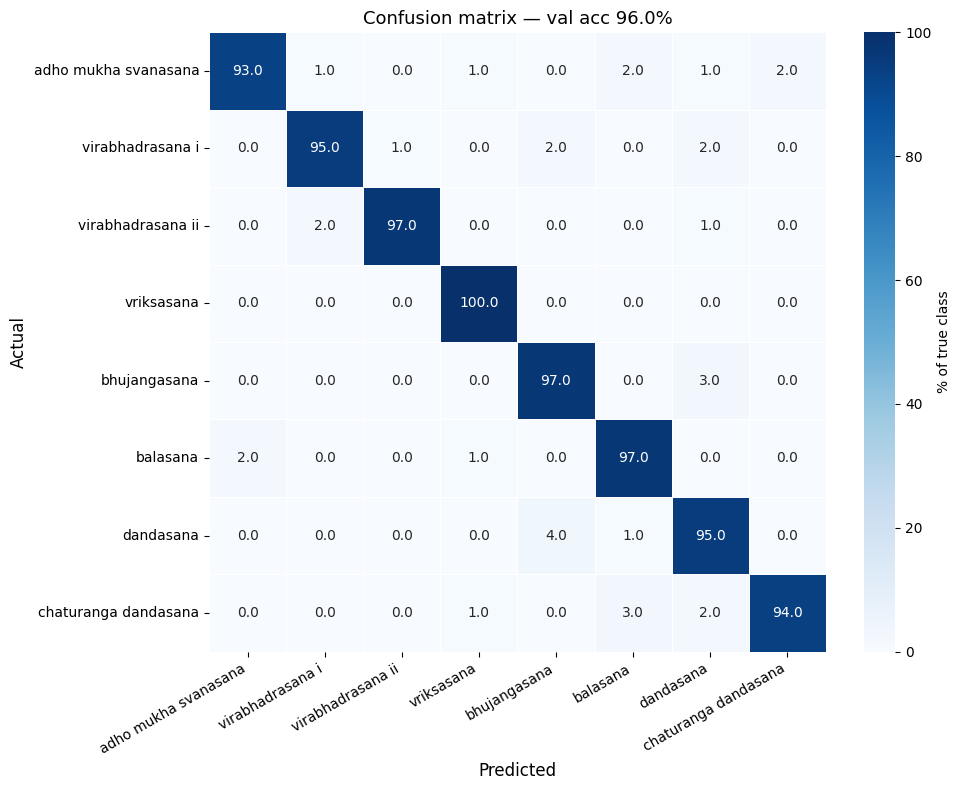


Most confused pairs (excluding diagonal):
  dandasana       → bhujangasana   : 4.0%
  chaturanga dandasana → balasana       : 3.0%
  bhujangasana    → dandasana      : 3.0%


In [24]:
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of true class'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion matrix — val acc {best_val_acc*100:.1f}%', fontsize=13)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print worst-confused pairs
print('\nMost confused pairs (excluding diagonal):')
np.fill_diagonal(cm_pct, 0)
flat = cm_pct.flatten()
top3 = flat.argsort()[-3:][::-1]
for idx in top3:
    r, c = divmod(idx, len(CLASS_NAMES))
    print(f'  {CLASS_NAMES[r]:15s} → {CLASS_NAMES[c]:15s}: {cm_pct[r,c]:.1f}%')

## Cell 14 — Grad-CAM: see what the model looks at

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3d5090d67658dac408026bce96463c00ec9a36dee0b7058c87b4dc40576ca6d8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


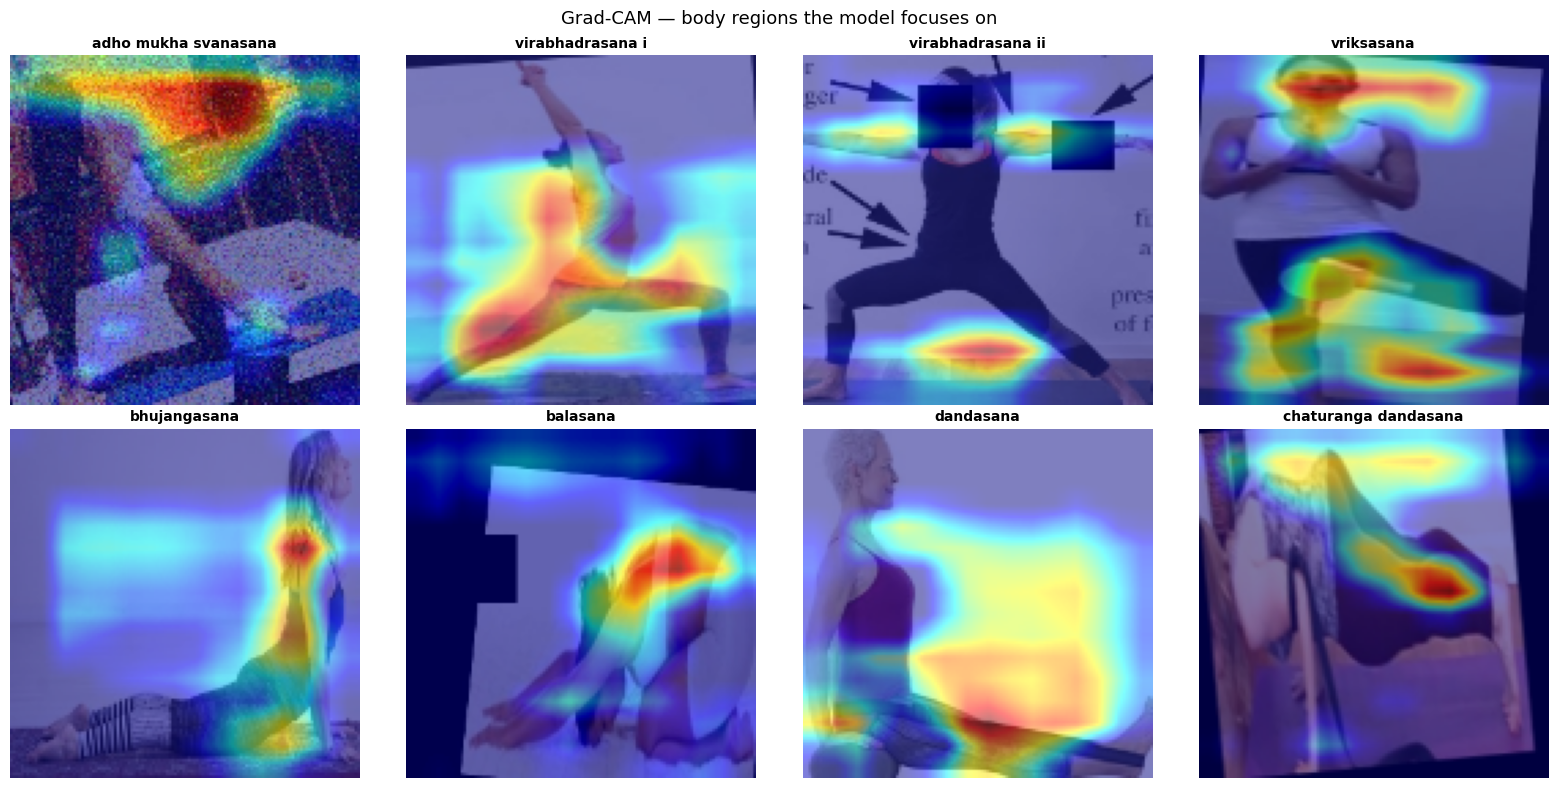

In [26]:
# !pip install grad-cam  # uncomment if needed
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Wrapper so GradCAM only sees the image branch
class CNNWrapper(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.model = full_model
    def forward(self, x):
        dummy_kp = torch.zeros(x.size(0), KP_DIM).to(x.device)
        return self.model(x, dummy_kp)

wrapper      = CNNWrapper(model)
target_layer = [model.cnn.block4.block[-2]]  # last BN before GAP
cam          = GradCAM(model=wrapper, target_layers=target_layer)

mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    imgs_p = list((VAL_DIR / cls).glob('*.jpg')) + list((VAL_DIR / cls).glob('*.png'))
    if not imgs_p: ax.axis('off'); continue
    raw  = cv2.cvtColor(cv2.imread(str(imgs_p[0])), cv2.COLOR_BGR2RGB)
    raw  = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    inp  = val_tf(image=raw)['image'].unsqueeze(0).to(DEVICE)
    mask = cam(input_tensor=inp)
    vis  = show_cam_on_image(raw / 255.0, mask[0], use_rgb=True)
    ax.imshow(vis)
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Grad-CAM — body regions the model focuses on', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Predict a single image

In [27]:
def predict(image_path: str, top_k: int = 3):
    """Run inference on any image and show top-k predictions with confidence bar."""
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    inp = val_tf(image=img)['image'].unsqueeze(0).to(DEVICE)
    kp  = torch.tensor(extract_keypoints(image_path)).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(inp, kp), dim=1).squeeze().cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
    ax1.axis('off')
    conf = probs[top_idx[0]] * 100
    ax1.set_title(f'Prediction: {CLASS_NAMES[top_idx[0]]}\nConfidence: {conf:.1f}%',
                  fontsize=12, fontweight='bold')

    colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(top_k)]
    bars   = [CLASS_NAMES[i] for i in top_idx][::-1]
    vals   = [probs[i] * 100 for i in top_idx][::-1]
    ax2.barh(bars, vals, color=colors[::-1])
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Top {top_k} predictions')
    ax2.set_xlim(0, 100)
    for i, v in enumerate(vals):
        ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
    return CLASS_NAMES[top_idx[0]], conf


# Usage:
# predict('path/to/your/yoga_image.jpg')
print('predict() is ready. Example: predict("test_image.jpg")')

predict() is ready. Example: predict("test_image.jpg")


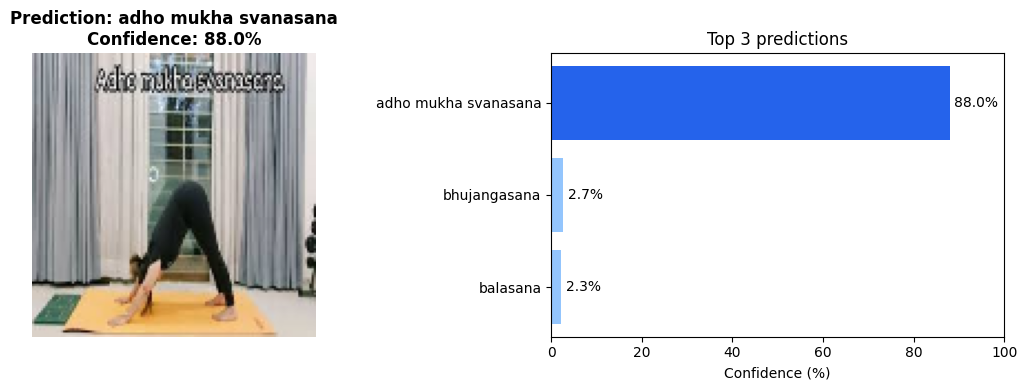

('adho mukha svanasana', np.float32(88.02463))

In [32]:
predict("/content/drive/MyDrive/Yoga-pose-detection ML project/ams2.jpg")

## Cell 16 — Tips if accuracy is below 85%

In [29]:
tips = """
IF ACCURACY < 85% — try these in order:

1. More data — biggest single improvement
   - Collect 50 more images for each confused class
   - Use Google Images / Pexels with pose name as query

2. Increase augmentation
   - Raise rotate_limit to 20
   - Add A.ElasticTransform(p=0.2)
   - Add A.GridDistortion(p=0.2)

3. Increase model capacity
   - Change block4: ConvBlock(256, 512)
   - Increase IMG_SIZE to 160

4. Train longer
   - Increase EPOCHS to 80
   - Reduce LR to 5e-4

5. Test-Time Augmentation (TTA)
   - Average predictions over flipped + original image
"""
print(tips)


IF ACCURACY < 85% — try these in order:

1. More data — biggest single improvement
   - Collect 50 more images for each confused class
   - Use Google Images / Pexels with pose name as query

2. Increase augmentation
   - Raise rotate_limit to 20
   - Add A.ElasticTransform(p=0.2)
   - Add A.GridDistortion(p=0.2)

3. Increase model capacity
   - Change block4: ConvBlock(256, 512)
   - Increase IMG_SIZE to 160

4. Train longer
   - Increase EPOCHS to 80
   - Reduce LR to 5e-4

5. Test-Time Augmentation (TTA)
   - Average predictions over flipped + original image



**FOR MODEL DOWNLOAD**

In [30]:
import torch
from pathlib import Path

# Create folder
Path('checkpoints').mkdir(exist_ok=True)

# Save complete model info
torch.save({
    'model_state_dict'  : model.state_dict(),
    'class_names'       : CLASS_NAMES,
    'num_classes'       : NUM_CLASSES,
    'img_size'          : IMG_SIZE,
    'kp_dim'            : KP_DIM,
    'val_accuracy'      : best_val_acc,
}, '/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_model_1.pth')

print(f'Model saved! Val accuracy: {best_val_acc*100:.2f}%')

Model saved! Val accuracy: 96.00%


In [33]:
# # Uncomment to save to Drive
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copytree(
    '/content/data/yoga_split',
    '/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/final',
    dirs_exist_ok=True
)
print('Saved to Google Drive!')
print('Uncomment the lines above to save to Google Drive.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive!
Uncomment the lines above to save to Google Drive.
